In [ ]:
# Single layer Perceptron without any library 

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=10):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.weights = []
        self.bias = 0


    # self Activation function 
    def activation(self,x):
        if x >= 0:
            return 1
        else:
            return 0

    # Training function
    def train(self, training_inputs, labels):
        # Initialize weights with 0
        self.weights = [0] * len(training_inputs[0])
        self.bias = 0

        # Trainig Loop
        for epoch in range (self.epochs):
            print(f"Epoch {epoch +1}")
            for i in range (len(training_inputs)):
                linear_output = 0

                # Calculate weighted sum
                for j in range(len(self.weights)):
                    linear_output += training_inputs[i][j] * self.weights[j]

                linear_output +=self.bias

                # Apply activation function
                prediction = self.activation(linear_output)

                # calculate error
                error = labels[i] - prediction

                # Update weights and bias
                for j in range(len(self.weights)):
                    self.weights[j] += self.learning_rate * error * training_inputs[i][j]

                self.bias += self.learning_rate * error

                print(f"Input: {training_inputs[i]}, Prediction: {prediction}, Error: {error}")
            
            print("Weights:",self.weights)
            print("Bias:",self.bias)
            print("-" * 30)

    # Pridiction function 
    def predict(self,inputs):
        linear_output = 0
        for j in range(len(self.weights)):
            linear_output += inputs[j] * self.weights[j]
        linear_output += self.bias
        return self.activation(linear_output)

#  Example : AND Gate
training_inputs = [
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]

labels = [0,0,0,1]

# Create Perceptron
p = Perceptron(learning_rate=0.1, epochs=10)

# Train
p.train(training_inputs, labels)

# Test
print("Testing")
for data in training_inputs:
    print(f"{data} -> {p.predict(data)}")
    
                
                    



Epoch 1
Input: [0, 0], Prediction: 1, Error: -1
Input: [0, 1], Prediction: 0, Error: 0
Input: [1, 0], Prediction: 0, Error: 0
Input: [1, 1], Prediction: 0, Error: 1
Weights: [0.1, 0.1]
Bias: 0.0
------------------------------
Epoch 2
Input: [0, 0], Prediction: 1, Error: -1
Input: [0, 1], Prediction: 1, Error: -1
Input: [1, 0], Prediction: 0, Error: 0
Input: [1, 1], Prediction: 0, Error: 1
Weights: [0.2, 0.1]
Bias: -0.1
------------------------------
Epoch 3
Input: [0, 0], Prediction: 0, Error: 0
Input: [0, 1], Prediction: 1, Error: -1
Input: [1, 0], Prediction: 1, Error: -1
Input: [1, 1], Prediction: 0, Error: 1
Weights: [0.2, 0.1]
Bias: -0.20000000000000004
------------------------------
Epoch 4
Input: [0, 0], Prediction: 0, Error: 0
Input: [0, 1], Prediction: 0, Error: 0
Input: [1, 0], Prediction: 0, Error: 0
Input: [1, 1], Prediction: 1, Error: 0
Weights: [0.2, 0.1]
Bias: -0.20000000000000004
------------------------------
Epoch 5
Input: [0, 0], Prediction: 0, Error: 0
Input: [0, 1]

In [3]:
# importing the library
import numpy as np

# Creating the input array
X=np.array([[1,0,1,0],[1,0,1,1],[0,1,0,1]])
print('\n input:')
print(X)

# Creating the output array
y=np.array([[1],[1],[0]])
print('\n Actual Output')
print(y)

# Defining the sigmoid function
def sigmoid(x):
    return 1/(1 + np.exp(-x))

# derivative of Sigmoid function
def derivatives_sigmoid(x):
    return x * (1 - x)


# initializing the variables
epoch=5000  # number of training iterations
lr=0.2 # learning rate 
inputlayer_neurons = X.shape[1]  # number of features in data set 
hiddenlayer_neurons = 3  # number of hidden layers neurons
output_neurons = 1 # number of neurons at output layer 

# initializing weight and bias 
wh = np.random.uniform(size=(inputlayer_neurons,hiddenlayer_neurons))
bh = np.random.uniform(size=(1,hiddenlayer_neurons))
wout = np.random.uniform(size=(hiddenlayer_neurons,output_neurons))
bout = np.random.uniform(size=(1,output_neurons))

# training the model 
for i in range(epoch):

    # forward propogation
    hidden_layer_input1 = np.dot(X,wh)
    hidden_layer_input = hidden_layer_input1 + bh
    hiddenlayer_activations = sigmoid(hidden_layer_input)
    output_layer_input1 = np.dot(hiddenlayer_activations,wout)
    output_layer_input = output_layer_input1 + bout
    output = sigmoid(output_layer_input)

    # Backpropagation
    E = y-output
    slope_output_layer = derivatives_sigmoid(output)
    slope_hidden_layer = derivatives_sigmoid(hiddenlayer_activations)
    d_output = E * slope_output_layer
    Error_at_hidden_layer = d_output.dot(wout.T)
    d_hiddenlayer = Error_at_hidden_layer * slope_hidden_layer
    wout += hiddenlayer_activations.T.dot(d_output)*lr
    bout += np.sum(d_output, axis=0, keepdims=True)*lr
    wh += X.T.dot(d_hiddenlayer)*lr
    bh += np.sum(d_hiddenlayer, axis=0, keepdims=True)*lr

print("\n Output from the model")
print(output)




 input:
[[1 0 1 0]
 [1 0 1 1]
 [0 1 0 1]]

 Actual Output
[[1]
 [1]
 [0]]

 Output from the model
[[0.98466598]
 [0.97511452]
 [0.03207629]]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8246 - loss: 0.7169 - val_accuracy: 0.9112 - val_loss: 0.3523
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8986 - loss: 0.3789 - val_accuracy: 0.9248 - val_loss: 0.2845
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9090 - loss: 0.3318 - val_accuracy: 0.9277 - val_loss: 0.2642
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9141 - loss: 0.3103 - val_accuracy: 0.9313 - val_loss: 0.2500
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9178 - loss: 0.2973 - val_accuracy: 0.9320 - val_loss: 0.2431
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9201 - loss: 0.2884 - val_accuracy: 0.9333 - val_loss: 0.2373
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2815 - val_accuracy: 0.9363 - val_loss: 0.2330
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step -

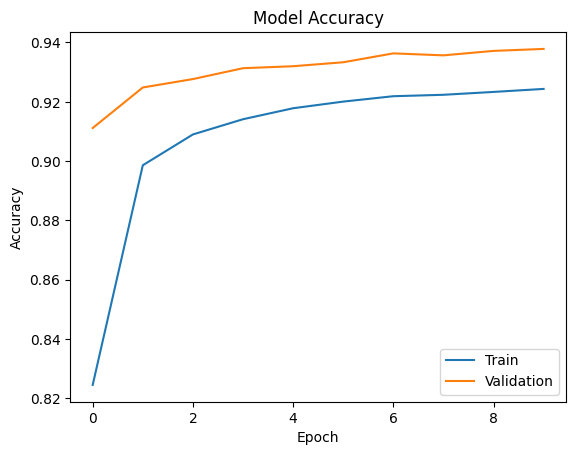

In [5]:
import numpy as np 
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.initializers import RandomNormal

# 1. Load MNIST
(x_train, y_train),(x_test, y_test) = mnist.load_data()

# 2. Normalize 
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 4. Input layer
input_layer = Input(shape=(28,28))

# 5. Flatten
x = Flatten()(input_layer) 

# 6. single layer perceptron
output = Dense(
    10,
    activation="softmax",
    kernel_initializer=RandomNormal(mean=0.0, stddev=0.05)
)(x)

# 7. Create model
model = Model(inputs=input_layer, outputs=output)

# 8. Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 9. Train
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

# 10. Evaluate
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

# 11. Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

